<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_V36B_Primary_Measured_Dataset_Lock_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — V36B Primary Measured Dataset Lock

This notebook locks one primary measured elastic electron-scattering dataset before V36C.

It does not compute ECSM predictions or residuals.

In [8]:
from pathlib import Path
import json, zipfile, hashlib
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("/content") if Path("/content").exists() else Path("/mnt/data")
OUT = BASE / "ecsm_electron_like_v36b_primary_measured_dataset_lock_out"
OUT.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT)

Output directory: /content/ecsm_electron_like_v36b_primary_measured_dataset_lock_out


In [9]:
protocol_lock = {
  "run_label": "V36B_primary_measured_dataset_lock",
  "status": "AWAITING_PRIMARY_MEASURED_DATASET_CSV",
  "inherits": {
    "V35": "PASS_FROZEN_MEASURED_SCATTERING_PROTOCOL_READY",
    "V36A": "PASS_V36_DATASET_ADMISSIBILITY_LOCK_READY"
  },
  "purpose": "Lock one schema-valid primary measured elastic electron-scattering dataset before any ECSM residuals are computed.",
  "frozen_values": {
    "q_eff": -0.9993035720499918,
    "E_rest_keV": 514.0698767738036,
    "alpha_fs": 0.0072973525692838015,
    "k_response_keV": 5140.698767738036,
    "r_rms_response_fm": 38.385244752791856,
    "Pi_ecsm_plateau_locked": 0.007146727844882419,
    "form_factor": "F(q)=exp[-(q/k_response)^2/6]"
  },
  "primary_domain_q_keV": [
    0.0,
    1268.2050944324717
  ],
  "secondary_domain_q_keV": [
    1268.2050944324717,
    10979.69097571184
  ],
  "required_columns": [
    "dataset_id",
    "source_reference",
    "beam_energy_keV",
    "observable"
  ],
  "one_of_required_columns": [
    "theta_deg",
    "q_transfer_keV"
  ],
  "optional_columns": [
    "sigma",
    "normalisation_reference",
    "notes"
  ],
  "residuals_computed": False,
"ecsm_prediction_computed": False
}
(OUT / "v36b_primary_dataset_lock_protocol.json").write_text(json.dumps(protocol_lock, indent=2))
print(json.dumps(protocol_lock, indent=2))

{
  "run_label": "V36B_primary_measured_dataset_lock",
  "status": "AWAITING_PRIMARY_MEASURED_DATASET_CSV",
  "inherits": {
    "V35": "PASS_FROZEN_MEASURED_SCATTERING_PROTOCOL_READY",
    "V36A": "PASS_V36_DATASET_ADMISSIBILITY_LOCK_READY"
  },
  "purpose": "Lock one schema-valid primary measured elastic electron-scattering dataset before any ECSM residuals are computed.",
  "frozen_values": {
    "q_eff": -0.9993035720499918,
    "E_rest_keV": 514.0698767738036,
    "alpha_fs": 0.0072973525692838015,
    "k_response_keV": 5140.698767738036,
    "r_rms_response_fm": 38.385244752791856,
    "Pi_ecsm_plateau_locked": 0.007146727844882419,
    "form_factor": "F(q)=exp[-(q/k_response)^2/6]"
  },
  "primary_domain_q_keV": [
    0.0,
    1268.2050944324717
  ],
  "secondary_domain_q_keV": [
    1268.2050944324717,
    10979.69097571184
  ],
  "required_columns": [
    "dataset_id",
    "source_reference",
    "beam_energy_keV",
    "observable"
  ],
  "one_of_required_columns": [
    "theta

In [10]:
template_cols = ["dataset_id","source_reference","beam_energy_keV","theta_deg","q_transfer_keV","observable","sigma","normalisation_reference","notes"]
schema_template = pd.DataFrame(columns=template_cols)
schema_template.to_csv(OUT / "v36b_primary_dataset_template.csv", index=False)
display(schema_template)

,dataset_id,source_reference,beam_energy_keV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes


In [11]:
# CELL 4 — LOAD AND LOCK PRIMARY MEASURED DATASET

from pathlib import Path
import hashlib
import json
import pandas as pd

CSV_PATH = "/content/v36b_primary_measured_dataset_sevoflurane_vukalovic2022_table1.csv"

required_cols = set(protocol_lock["required_columns"])
one_of_cols = set(protocol_lock["one_of_required_columns"])

dataset_status = {
    "dataset_supplied": False,
    "primary_dataset_locked": False,
    "admissibility_label": "PENDING_PRIMARY_DATASET_UPLOAD",
    "ecsm_prediction_computed": False,
    "measured_residuals_computed": False
}

csv_path = Path(CSV_PATH)

if not csv_path.exists():
    raise FileNotFoundError(
        f"CSV not found at {csv_path}. Upload the CSV into the Colab file panel, "
        "then check the exact file path."
    )

df = pd.read_csv(csv_path)

missing_required = sorted(required_cols - set(df.columns))
has_theta_or_q = bool(one_of_cols & set(df.columns))

numeric_errors = []
for col in ["beam_energy_keV", "observable"]:
    if col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.isna().any():
            numeric_errors.append(f"{col} has missing/non-numeric values")

schema_pass = (not missing_required) and has_theta_or_q and not numeric_errors

sha256 = hashlib.sha256(csv_path.read_bytes()).hexdigest()

if schema_pass:
    locked_copy = OUT / "locked_primary_measured_dataset_v36b.csv"
    df.to_csv(locked_copy, index=False)

dataset_status = {
    "dataset_supplied": True,
    "primary_dataset_locked": bool(schema_pass),
    "admissibility_label": "PASS_PRIMARY_MEASURED_DATASET_LOCK_READY" if schema_pass else "FAIL_PRIMARY_MEASURED_DATASET_LOCK",
    "n_rows": int(len(df)),
    "n_columns": int(len(df.columns)),
    "columns": list(df.columns),
    "missing_required_columns": missing_required,
    "has_theta_or_q": has_theta_or_q,
    "numeric_errors": numeric_errors,
    "csv_sha256": sha256,
    "ecsm_prediction_computed": False,
    "measured_residuals_computed": False,
}

(OUT / "v36b_supplied_primary_dataset_lock_status.json").write_text(
    json.dumps(dataset_status, indent=2)
)

print(json.dumps(dataset_status, indent=2))
display(df.head())

{
  "dataset_supplied": true,
  "primary_dataset_locked": true,
  "admissibility_label": "PASS_PRIMARY_MEASURED_DATASET_LOCK_READY",
  "n_rows": 126,
  "n_columns": 10,
  "columns": [
    "dataset_id",
    "source_reference",
    "beam_energy_keV",
    "beam_energy_eV",
    "theta_deg",
    "q_transfer_keV",
    "observable",
    "sigma",
    "normalisation_reference",
    "notes"
  ],
  "missing_required_columns": [],
  "has_theta_or_q": true,
  "numeric_errors": [],
  "csv_sha256": "5e883d9cbf7ec7629c604a2527ddc6abc4acdf8c1ae6edc0dd37d3e39d5b3b81",
  "ecsm_prediction_computed": false,
  "measured_residuals_computed": false
}


,dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes
0,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,25,3.094478,3.60,1.10,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
1,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,30,3.700385,3.07,0.93,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
2,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,35,4.299247,2.17,0.66,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
3,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,40,4.889926,1.89,0.43,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
4,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,45,5.471297,1.77,0.40,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...


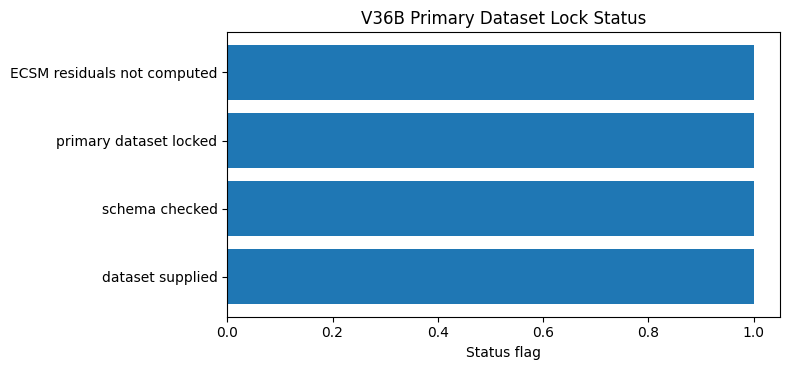

In [12]:
plot_items = [
    ("dataset supplied", 1 if dataset_status.get("dataset_supplied") else 0),
    ("schema checked", 1 if dataset_status.get("dataset_supplied") else 0),
    ("primary dataset locked", 1 if dataset_status.get("primary_dataset_locked") else 0),
    ("ECSM residuals not computed", 1),
]
plot_df = pd.DataFrame(plot_items, columns=["item", "status"])

plt.figure(figsize=(8, 3.8))
plt.barh(plot_df["item"], plot_df["status"])
plt.xlabel("Status flag")
plt.title("V36B Primary Dataset Lock Status")
plt.tight_layout()
plt.savefig(OUT / "fig_v36b_primary_dataset_lock_status.png", dpi=200)
plt.show()

Final label: PASS_PRIMARY_MEASURED_DATASET_LOCK_READY
{
  "run_label": "V36B_primary_measured_dataset_lock",
  "final_label": "PASS_PRIMARY_MEASURED_DATASET_LOCK_READY",
  "n_pass": 13,
  "n_criteria": 13,
  "primary_dataset_locked": true,
  "dataset_supplied": true,
  "ecsm_prediction_computed": false,
  "measured_residuals_computed": false,
  "next_step": "If PASS, run V36C. If pending, provide a schema-valid measured dataset CSV."
}


,criterion,value,pass
0,inherits V35 frozen protocol,1.000000,True
1,inherits V36A dataset-admissibility lock,1.000000,True
2,frozen values carried forward,1.000000,True
3,primary q-domain carried forward,1268.205094,True
4,secondary q-domain carried forward,10979.690976,True
5,required schema template exported,1.000000,True
6,no ECSM prediction computed,0.000000,True
7,no residuals computed,0.000000,True
8,measured dataset supplied,1.000000,True
9,required columns present,1.000000,True


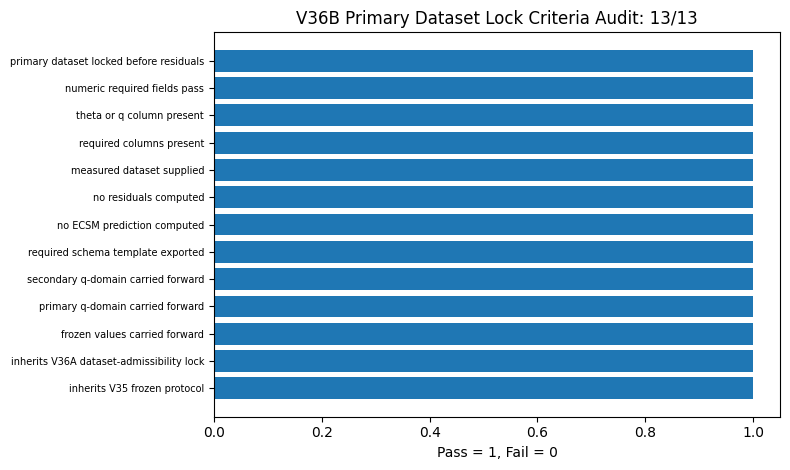

In [13]:
base_criteria = [
    ("inherits V35 frozen protocol", 1.0, True),
    ("inherits V36A dataset-admissibility lock", 1.0, True),
    ("frozen values carried forward", 1.0, True),
    ("primary q-domain carried forward", protocol_lock["primary_domain_q_keV"][1], True),
    ("secondary q-domain carried forward", protocol_lock["secondary_domain_q_keV"][1], True),
    ("required schema template exported", 1.0, True),
    ("no ECSM prediction computed", 0.0, not dataset_status.get("ecsm_prediction_computed", False)),
    ("no residuals computed", 0.0, not dataset_status.get("measured_residuals_computed", False)),
]
if dataset_status.get("dataset_supplied"):
    lock_criteria = [
        ("measured dataset supplied", 1.0, True),
        ("required columns present", 0.0 if dataset_status.get("missing_required_columns") else 1.0, not dataset_status.get("missing_required_columns")),
        ("theta or q column present", 1.0 if dataset_status.get("has_theta_or_q") else 0.0, dataset_status.get("has_theta_or_q")),
        ("numeric required fields pass", 0.0 if dataset_status.get("numeric_errors") else 1.0, not dataset_status.get("numeric_errors")),
        ("primary dataset locked before residuals", 1.0 if dataset_status.get("primary_dataset_locked") else 0.0, dataset_status.get("primary_dataset_locked")),
    ]
else:
    lock_criteria = [("dataset lock pending until CSV supplied", 1.0, True)]

criteria_df = pd.DataFrame(base_criteria + lock_criteria, columns=["criterion", "value", "pass"])
criteria_df.to_csv(OUT / "v36b_primary_dataset_lock_criteria.csv", index=False)

n_pass = int(criteria_df["pass"].sum())
n_criteria = len(criteria_df)
if dataset_status.get("primary_dataset_locked"):
    final_label = "PASS_PRIMARY_MEASURED_DATASET_LOCK_READY"
elif dataset_status.get("dataset_supplied"):
    final_label = "FAIL_PRIMARY_MEASURED_DATASET_LOCK"
else:
    final_label = "PENDING_PRIMARY_DATASET_UPLOAD"

run_summary = {
    "run_label": "V36B_primary_measured_dataset_lock",
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "primary_dataset_locked": bool(dataset_status.get("primary_dataset_locked", False)),
    "dataset_supplied": bool(dataset_status.get("dataset_supplied", False)),
    "ecsm_prediction_computed": False,
    "measured_residuals_computed": False,
    "next_step": "If PASS, run V36C. If pending, provide a schema-valid measured dataset CSV."
}
(OUT / "run_summary_v36b.json").write_text(json.dumps(run_summary, indent=2))
pd.DataFrame([run_summary]).to_csv(OUT / "final_v36b_dataset_lock_verdict.csv", index=False)

print("Final label:", final_label)
print(json.dumps(run_summary, indent=2))
display(criteria_df)

plt.figure(figsize=(8, 4.8))
criteria_plot = criteria_df.copy()
criteria_plot["status"] = criteria_plot["pass"].astype(int)
plt.barh(range(len(criteria_plot)), criteria_plot["status"])
plt.yticks(range(len(criteria_plot)), criteria_plot["criterion"], fontsize=7)
plt.xlabel("Pass = 1, Fail = 0")
plt.title(f"V36B Primary Dataset Lock Criteria Audit: {n_pass}/{n_criteria}")
plt.tight_layout()
plt.savefig(OUT / "fig_v36b_primary_dataset_lock_criteria_audit.png", dpi=200)
plt.show()

In [14]:
manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT / "output_manifest_v36b.csv", index=False)

zip_path = BASE / "ecsm_electron_like_v36b_primary_measured_dataset_lock_out.zip"
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        z.write(p, arcname=p.name)

print("Output directory:", OUT)
print("Zip file:", zip_path)
display(manifest)

Output directory: /content/ecsm_electron_like_v36b_primary_measured_dataset_lock_out
Zip file: /content/ecsm_electron_like_v36b_primary_measured_dataset_lock_out.zip


,file
0,fig_v36b_primary_dataset_lock_criteria_audit.png
1,fig_v36b_primary_dataset_lock_status.png
2,final_v36b_dataset_lock_verdict.csv
3,locked_primary_measured_dataset_v36b.csv
4,output_manifest_v36b.csv
5,run_summary_v36b.json
6,v36b_primary_dataset_lock_criteria.csv
7,v36b_primary_dataset_lock_protocol.json
8,v36b_primary_dataset_template.csv
9,v36b_supplied_primary_dataset_lock_status.json
